In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

In [32]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

In [33]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [34]:
train.shape

(421570, 5)

In [35]:
train = train.merge(features, on=["Store","Date","IsHoliday"])
train = train.merge(stores, on="Store")

In [36]:
test = test.merge(features, on=["Store","Date","IsHoliday"])
test = test.merge(stores, on="Store")

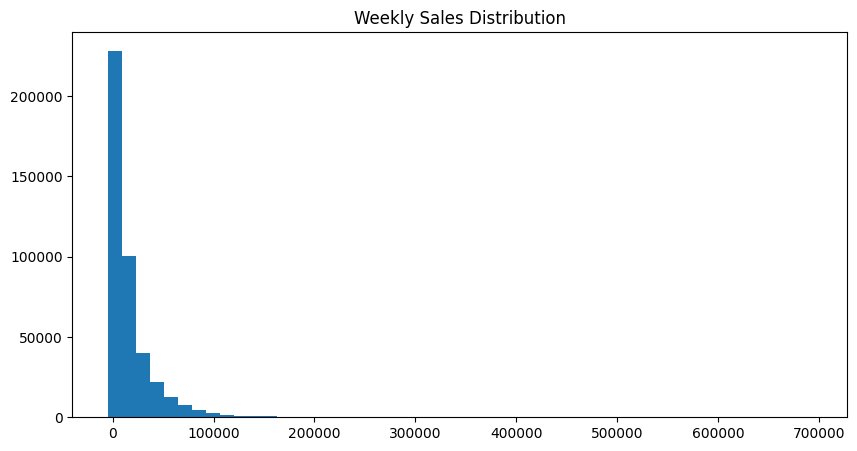

In [37]:
plt.figure(figsize=(10,5))
plt.hist(train["Weekly_Sales"], bins=50)
plt.title("Weekly Sales Distribution")
plt.show()

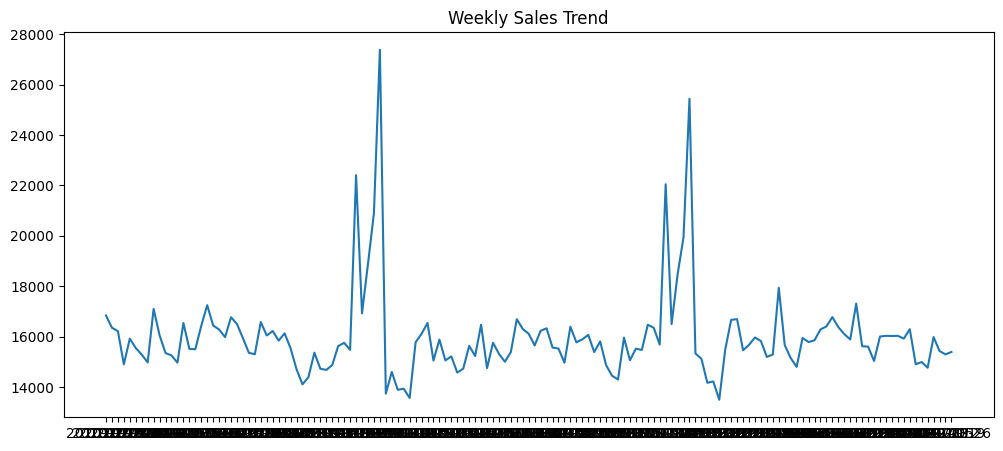

In [38]:
sales_trend = train.groupby("Date")["Weekly_Sales"].mean()

plt.figure(figsize=(12,5))
plt.plot(sales_trend)
plt.title("Weekly Sales Trend")
plt.show()

In [39]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Week"] = train["Date"].dt.isocalendar().week

test["Year"] = test["Date"].dt.year
test["Month"] = test["Date"].dt.month
test["Week"] = test["Date"].dt.isocalendar().week

In [40]:
train.isnull().sum().sort_values(ascending=False).head(20)

,0
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138
Store,0
Dept,0
Date,0
Fuel_Price,0
IsHoliday,0


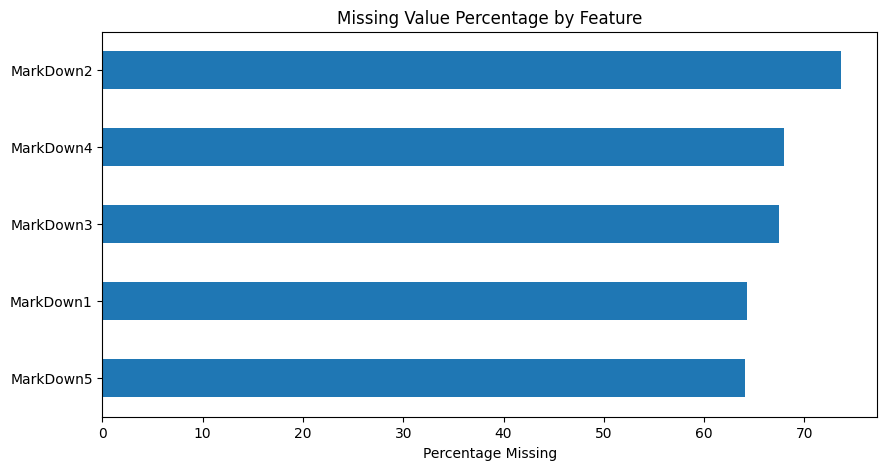

In [41]:
missing = train.isnull().sum()
missing = missing[missing > 0]

missing_percent = (missing / len(train)) * 100

missing_percent.sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Percentage Missing")
plt.show()

In [42]:
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

In [43]:
train.isnull().sum().sum()

np.int64(0)

In [44]:
train = pd.get_dummies(train, columns=["Type"])
test = pd.get_dummies(test, columns=["Type"])

In [45]:
train["IsHoliday"] = train["IsHoliday"].astype(int)
test["IsHoliday"] = test["IsHoliday"].astype(int)

Drop Non-Useful Column like date

In [46]:
train = train.drop(["Date"], axis=1)
test = test.drop(["Date"], axis=1)

In [47]:
print(train.shape)
print(test.shape)

(421570, 20)
(115064, 19)


Correlation Plot

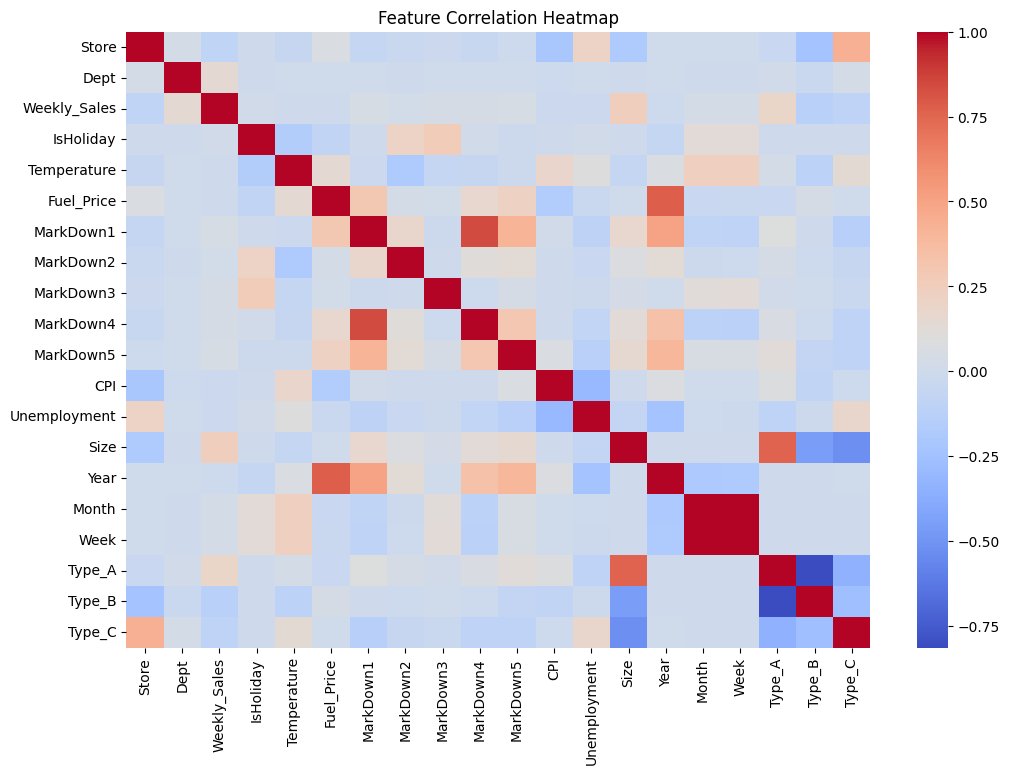

In [48]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [49]:
X_train = train.drop("Weekly_Sales", axis=1)
y_train = train["Weekly_Sales"]

X_test = test

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

scaling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

convert to pytorch

In [52]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

In [53]:
X_train = X_train.unsqueeze(1)
X_val = X_val.unsqueeze(1)
X_test = X_test.unsqueeze(1)

In [54]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

torch.Size([337256, 1, 19])
torch.Size([84314, 1, 19])
torch.Size([115064, 1, 19])


In [55]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

In [56]:
import torch.nn as nn
import torch

class RetailModel(nn.Module):

    def __init__(self, input_size):
        super(RetailModel, self).__init__()

        # CNN Layer
        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=32,
            kernel_size=2
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=64,
            batch_first=True
        )

        # Fully Connected
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = x.permute(0,2,1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [57]:
model = RetailModel(X_train.shape[2])

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

RetailModel(
  (conv1): Conv1d(1, 32, kernel_size=(2,), stride=(1,))
  (lstm): LSTM(32, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [59]:
epochs = 20

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)


    model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            val_output = model(X_batch)
            val_loss = criterion(val_output.squeeze(), y_batch)
            total_val_loss += val_loss.item()

    val_loss = total_val_loss / len(val_loader)
    val_losses.append(val_loss)


    print(f"""
Epoch [{epoch+1}/{epochs}]
Train Loss : {train_loss:.4f}
Val Loss   : {val_loss:.4f}
""")


Epoch [1/20]
Train Loss : 758570884.7102
Val Loss   : 745398877.2848


Epoch [2/20]
Train Loss : 704043328.8741
Val Loss   : 673745408.9697


Epoch [3/20]
Train Loss : 628400364.8194
Val Loss   : 599842458.9576


Epoch [4/20]
Train Loss : 564831159.6965
Val Loss   : 549310515.3939


Epoch [5/20]
Train Loss : 528951255.0653
Val Loss   : 527143965.2848


Epoch [6/20]
Train Loss : 508077780.2489
Val Loss   : 492569364.5576


Epoch [7/20]
Train Loss : 470180050.2337
Val Loss   : 457179431.3697


Epoch [8/20]
Train Loss : 433269938.3794
Val Loss   : 427697029.7212


Epoch [9/20]
Train Loss : 408107644.1639
Val Loss   : 400991328.3879


Epoch [10/20]
Train Loss : 388160253.4264
Val Loss   : 379156226.2303


Epoch [11/20]
Train Loss : 369737276.8923
Val Loss   : 363217419.9273


Epoch [12/20]
Train Loss : 352860947.6176
Val Loss   : 345638978.0364


Epoch [13/20]
Train Loss : 330074046.1305
Val Loss   : 329974325.6242


Epoch [14/20]
Train Loss : 308313136.0971
Val Loss   : 302968373.2364




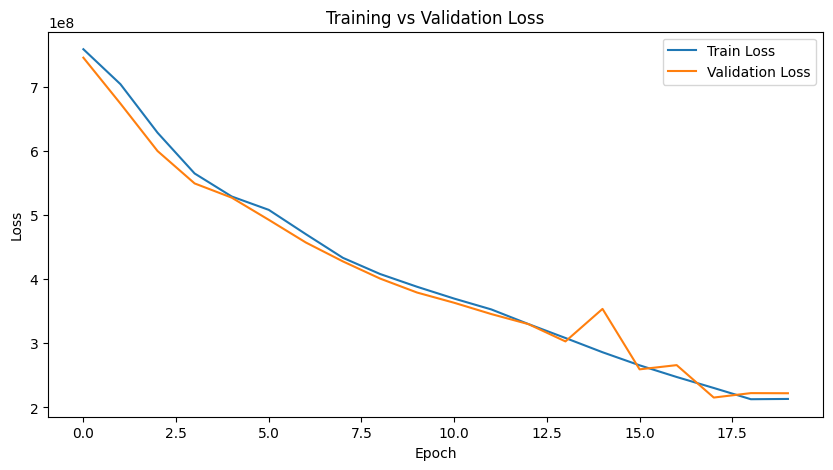

In [60]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()